# Distribution Basics

ProbPipe wraps [TensorFlow Probability (TFP)](https://www.tensorflow.org/probability) distributions with a unified API that follows TFP shape semantics (`sample_shape + batch_shape + event_shape`). On top of the standard TFP interface it adds:

- **Provenance tracking** -- every distribution records how it was created and from which parents.
- **Support constraints** -- each distribution declares its support (e.g. `real`, `positive`, `unit_interval`) so that cross-family conversions can be validated automatically.
- **Cross-family conversion** via `from_distribution()` -- moment-match any distribution into another family, with optional support checking.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probpipe import (
    Normal, Beta, Gamma, Exponential, MultivariateNormal, Wishart,
    Dirichlet, Poisson, Bernoulli, Categorical,
    EmpiricalDistribution, TransformedDistribution, Provenance,
)
from probpipe import expectation, mean, prob, sample, variance

key = jax.random.PRNGKey(0)

## Creating Distributions

Each distribution class wraps a TFP backend and stores its parameters as JAX arrays.  Construction mirrors TFP naming conventions (e.g. `loc`/`scale` for Normal, `concentration`/`rate` for Gamma).

In [2]:
n = Normal(loc=2.0, scale=0.5)
b = Beta(alpha=2.0, beta=5.0)
g = Gamma(concentration=3.0, rate=1.0)

for dist in [n, b, g]:
    print(f"{dist}")
    print(f"  event_shape={dist.event_shape}, batch_shape={dist.batch_shape}")
    print(f"  mean={float(mean(dist)):.4f}, var={float(variance(dist)):.4f}")
    print()

Normal(event_shape=())
  event_shape=(), batch_shape=()
  mean=2.0000, var=0.2500

Beta(event_shape=())
  event_shape=(), batch_shape=()
  mean=0.2857, var=0.0255

Gamma(event_shape=())
  event_shape=(), batch_shape=()
  mean=3.0000, var=3.0000



## Computing Expectations

The `expectation(f)` method estimates `E[f(X)]` for any function `f` – including ones that `.mean()` and `.variance()` cannot express. For parametric distributions with infinite support, the estimate uses Monte Carlo and returns a `BootstrapDistribution` that captures sampling error. For finite-support distributions (e.g., Categorical), it is exact.

In [3]:
from probpipe import BootstrapDistribution

# E[sin(X)] for a Normal -- no closed form, requires MC
n = Normal(loc=2.0, scale=0.5)
ex_sin = expectation(n, lambda x: jnp.sin(x), key=jax.random.PRNGKey(10), num_evaluations=5000)
print(f"E[sin(X)] for Normal(2, 0.5):")
print(f"  Estimate: {float(mean(ex_sin)):.4f}")   # ~sin(2) = 0.909, damped by variance
print(f"  MC std error: {float(jnp.sqrt(variance(ex_sin))):.4f}")
print(f"  Returns: {type(ex_sin).__name__}")
print()

# Exact expectation on a Categorical (finite support, no MC needed)
cat = Categorical(probs=jnp.array([0.1, 0.3, 0.4, 0.2]))
ex_cat = expectation(cat, lambda x: x**2)
print(f"E[X²] for Categorical: {float(ex_cat):.1f}")  # 0*.1+1*.3+4*.4+9*.2 = 3.7
print(f"  Returns: {type(ex_cat).__name__} (exact, no BootstrapDistribution)")
print()

# Disable error tracking with return_dist=False
ex_plain = n.expectation(lambda x: jnp.sin(x), key=jax.random.PRNGKey(10),
                          num_evaluations=5000, return_dist=False)
print(f"return_dist=False: {float(ex_plain):.4f} ({type(ex_plain).__name__})")

E[sin(X)] for Normal(2, 0.5):
  Estimate: 0.8000
  MC std error: 0.0033
  Returns: BootstrapDistribution

E[X²] for Categorical: 3.7
  Returns: ArrayImpl (exact, no BootstrapDistribution)

return_dist=False: 0.8000 (ArrayImpl)


## Sampling

Call `dist.sample(key, sample_shape)` to draw samples.  The returned array has shape `sample_shape + batch_shape + event_shape`, following the standard TFP convention.  Each call requires a JAX PRNG key for reproducibility.

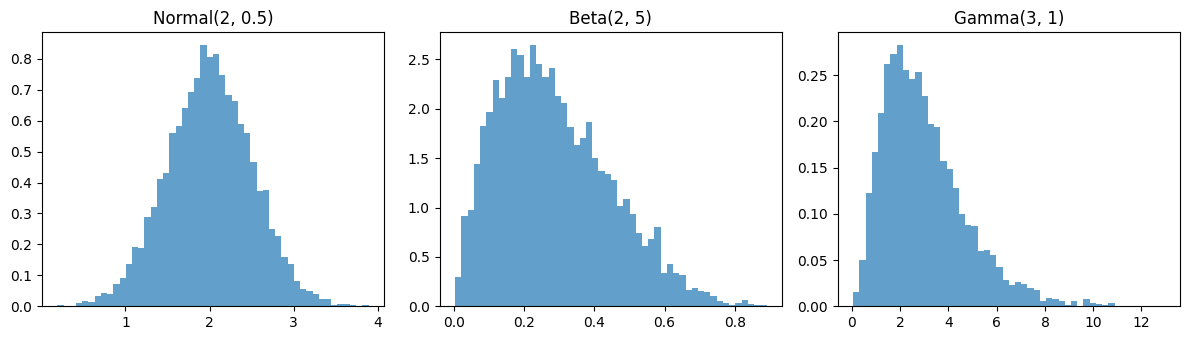

In [4]:
k1, k2, k3 = jax.random.split(key, 3)
samples_n = sample(n, key=k1, sample_shape=(5000,))
samples_b = sample(b, key=k2, sample_shape=(5000,))
samples_g = sample(g, key=k3, sample_shape=(5000,))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, s, label in zip(axes, [samples_n, samples_b, samples_g],
                         ["Normal(2, 0.5)", "Beta(2, 5)", "Gamma(3, 1)"]):
    ax.hist(s, bins=50, density=True, alpha=0.7)
    ax.set_title(label)
plt.tight_layout()
plt.show()

## Log-Probability and Density

`dist.log_prob(x)` returns the log-density (or log-mass for discrete distributions) at `x`.  The convenience method `dist.prob(x)` exponentiates the result.

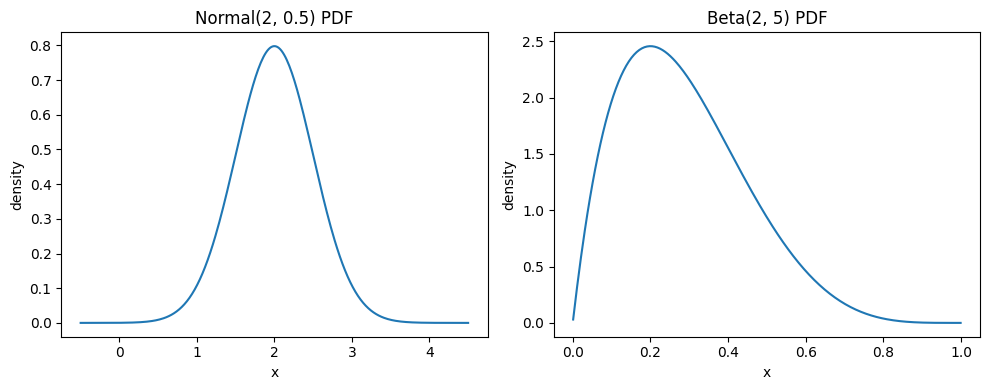

In [5]:
x_n = jnp.linspace(-0.5, 4.5, 300)
x_b = jnp.linspace(0.001, 0.999, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x_n, prob(n, x_n))
ax1.set_title("Normal(2, 0.5) PDF")
ax1.set_xlabel("x")
ax1.set_ylabel("density")

ax2.plot(x_b, prob(b, x_b))
ax2.set_title("Beta(2, 5) PDF")
ax2.set_xlabel("x")
ax2.set_ylabel("density")

plt.tight_layout()
plt.show()

## Multivariate Distributions

`MultivariateNormal` accepts a mean vector and either a covariance matrix (`cov=`) or a lower-triangular Cholesky factor (`scale_tril`).  `Dirichlet` lives on the probability simplex.

MultivariateNormal(event_shape=(2,))
  event_shape=(2,), mean=[ 1. -1.]


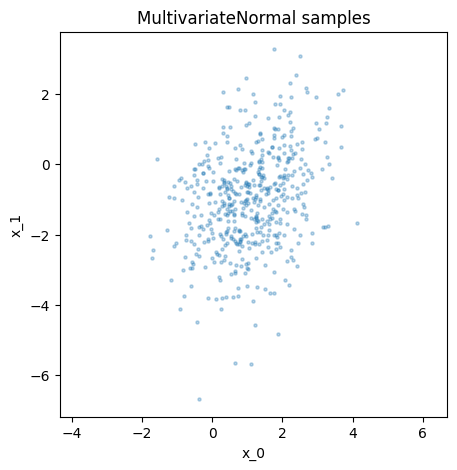

In [6]:
mvn = MultivariateNormal(
    loc=jnp.array([1.0, -1.0]),
    cov=jnp.array([[1.0, 0.5], [0.5, 2.0]]),
)
print(mvn)
print(f"  event_shape={mvn.event_shape}, mean={mean(mvn)}")

samples_mvn = sample(mvn, key=jax.random.PRNGKey(2), sample_shape=(500,))
plt.figure(figsize=(5, 5))
plt.scatter(samples_mvn[:, 0], samples_mvn[:, 1], alpha=0.3, s=5)
plt.title("MultivariateNormal samples")
plt.xlabel("x_0")
plt.ylabel("x_1")
plt.axis("equal")
plt.show()

Dirichlet(event_shape=(3,))
  event_shape=(3,), support=simplex
  mean=[0.25  0.625 0.125]


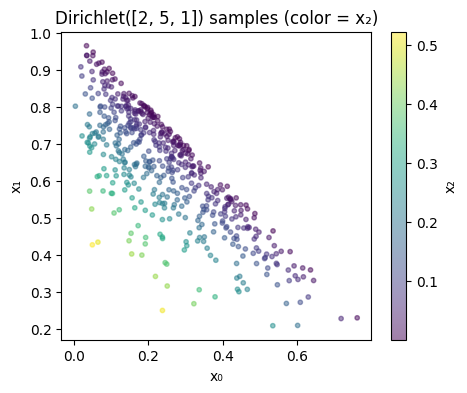

In [7]:
d = Dirichlet(concentration=jnp.array([2.0, 5.0, 1.0]))
print(d)
print(f"  event_shape={d.event_shape}, support={d.support}")
print(f"  mean={mean(d)}")

samples_d = sample(d, key=jax.random.PRNGKey(10), sample_shape=(500,))

# Ternary-style scatter: plot first two simplex coordinates
fig, ax = plt.subplots(figsize=(5, 4))
sc = ax.scatter(samples_d[:, 0], samples_d[:, 1], c=samples_d[:, 2],
                alpha=0.5, s=10, cmap="viridis")
ax.set_xlabel("x₀")
ax.set_ylabel("x₁")
ax.set_title("Dirichlet([2, 5, 1]) samples (color = x₂)")
plt.colorbar(sc, label="x₂")
plt.show()

## Flatten and Unflatten Values

Every `ArrayDistribution` provides `flatten_value()` and `unflatten_value()` methods that convert between the native event shape and a flat 1-D vector representation. For distributions whose events are already vectors (like `MultivariateNormal`), this is a no-op. For distributions with richer event shapes (like `Wishart`, whose events are matrices), flattening ravels the event dimensions into a single axis.

Both methods preserve all leading dimensions (`sample_shape` and/or `batch_shape`).

In [8]:
# --- MVN: event_shape=(d,), so flatten is essentially a no-op ---
mvn = MultivariateNormal(loc=jnp.zeros(3), cov=jnp.eye(3))
print(f"MVN: event_shape={mvn.event_shape}, event_size={mvn.event_size}")

s = sample(mvn, key=jax.random.PRNGKey(20))
flat = mvn.flatten_value(s)
print(f"  s shape:    {s.shape}")
print(f"  flattened shape: {flat.shape}  (same — already a vector)")
print(f"  roundtrip match: {bool(jnp.allclose(sample, mvn.unflatten_value(flat)))}")

print()

# --- Wishart: event_shape=(d, d), flatten ravels the matrix ---
w = Wishart(df=5.0, scale=jnp.eye(3))
print(f"Wishart: event_shape={w.event_shape}, event_size={w.event_size}")

sample_w = sample(w, key=jax.random.PRNGKey(21))
flat_w = w.flatten_value(sample_w)
print(f"  sample shape:    {sample_w.shape}")
print(f"  flattened shape: {flat_w.shape}  (3×3 matrix → 9-vector)")
print(f"  roundtrip match: {bool(jnp.allclose(sample_w, w.unflatten_value(flat_w)))}")

MVN: event_shape=(3,), event_size=3


  sample shape:    (3,)
  flattened shape: (3,)  (same — already a vector)
  roundtrip match: True

Wishart: event_shape=(3, 3), event_size=9


  sample shape:    (3, 3)
  flattened shape: (9,)  (3×3 matrix → 9-vector)
  roundtrip match: True


In [9]:
# --- With sample_shape: leading sample dims are preserved ---
samples_w = sample(w, key=jax.random.PRNGKey(22), sample_shape=(50,))
flat_batch = w.flatten_value(samples_w)
print(f"Wishart with sample_shape=(50,):")
print(f"  samples shape:   {samples_w.shape}     (sample + event)")
print(f"  flattened shape: {flat_batch.shape}   (sample + event_size)")
print(f"  roundtrip match: {bool(jnp.allclose(samples_w, w.unflatten_value(flat_batch)))}")

print()

# --- With both sample_shape and batch_shape ---
# Batched Wishart: batch of 2 Wishart distributions over 3×3 matrices
w_batched = Wishart(df=jnp.array([5.0, 8.0]), scale=jnp.stack([jnp.eye(3), 2 * jnp.eye(3)]))
print(f"Batched Wishart: batch_shape={w_batched.batch_shape}, event_shape={w_batched.event_shape}")

samples_wb = sample(w_batched, key=jax.random.PRNGKey(23), sample_shape=(10, 4))
flat_wb = w_batched.flatten_value(samples_wb)
print(f"  samples shape:   {samples_wb.shape}  (sample + batch + event)")
print(f"  flattened shape: {flat_wb.shape}  (sample + batch + event_size)")
print(f"  roundtrip match: {bool(jnp.allclose(samples_wb, w_batched.unflatten_value(flat_wb)))}")

Wishart with sample_shape=(50,):
  samples shape:   (50, 3, 3)     (sample + event)
  flattened shape: (50, 9)   (sample + event_size)
  roundtrip match: True

Batched Wishart: batch_shape=(2,), event_shape=(3, 3)


  samples shape:   (10, 4, 2, 3, 3)  (sample + batch + event)
  flattened shape: (10, 4, 2, 9)  (sample + batch + event_size)
  roundtrip match: True


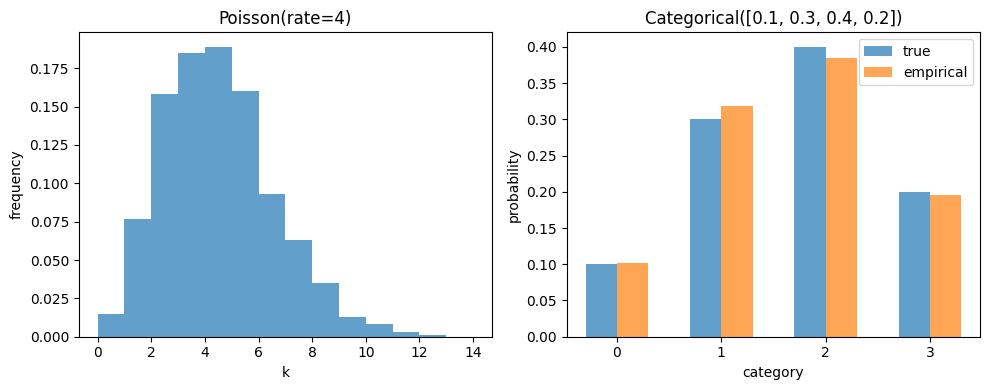

In [10]:
p = Poisson(rate=4.0)
cat = Categorical(probs=jnp.array([0.1, 0.3, 0.4, 0.2]))

samples_p = sample(p, key=jax.random.PRNGKey(3), sample_shape=(1000,))
samples_c = sample(cat, key=jax.random.PRNGKey(4), sample_shape=(1000,))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Poisson: histogram of counts
ax1.hist(samples_p, bins=range(15), density=True, alpha=0.7)
ax1.set_title("Poisson(rate=4)")
ax1.set_xlabel("k")
ax1.set_ylabel("frequency")

# Categorical: bar chart of empirical vs true probabilities
categories = jnp.arange(4)
true_probs = jnp.array([0.1, 0.3, 0.4, 0.2])
empirical_counts = jnp.array([(samples_c == k).sum() for k in categories])
empirical_probs = empirical_counts / empirical_counts.sum()

ax2.bar(categories - 0.15, true_probs, width=0.3, label="true", alpha=0.7)
ax2.bar(categories + 0.15, empirical_probs, width=0.3, label="empirical", alpha=0.7)
ax2.set_xticks(categories)
ax2.set_xticklabels(["0", "1", "2", "3"])
ax2.set_title("Categorical([0.1, 0.3, 0.4, 0.2])")
ax2.set_xlabel("category")
ax2.set_ylabel("probability")
ax2.legend()

plt.tight_layout()
plt.show()

## Named Distributions

Every distribution accepts an optional `name` keyword argument.  The name is surfaced in the `repr` and carried through operations like `from_distribution`, making it easy to track parameters in larger models.

In [11]:
prior = Normal(loc=0.0, scale=1.0, name="theta")
print(f"Name: {prior.name}")
print(f"Repr: {prior}")

Name: theta
Repr: Normal(name='theta', event_shape=())


## Support Constraints

Each distribution exposes a `.support` property that describes the set of values where the density/mass is non-zero.  This is used by `from_distribution()` to verify that a conversion makes sense before attempting it.

In [12]:
dists = [
    Normal(0, 1),
    Beta(2, 5),
    Gamma(3, 1),
    Poisson(rate=3),
    Bernoulli(probs=0.5),
]
for d in dists:
    print(f"{type(d).__name__:20s} support={d.support}")

Normal               support=real
Beta                 support=unit_interval
Gamma                support=positive
Poisson              support=non_negative_integer
Bernoulli            support=boolean


## Distribution Conversion (`from_distribution`)

Any distribution class provides a `from_distribution(other, ...)` classmethod that fits a new instance by moment-matching samples drawn from `other`.

By default, the method checks that the source support is compatible with the target.  For example, converting a `Gamma` (support=`positive`) to a `Normal` (support=`real`) is allowed because positive reals are a subset of all reals.  Converting a `Normal` (support=`real`) to a `Beta` (support=`unit_interval`) is **not** allowed, because real-valued samples can fall outside [0, 1].  You can override this with `check_support=False`.

In [13]:
g = Gamma(concentration=9.0, rate=1.0)  # mean=9, var=9

# Gamma (positive) -> Normal (real) is allowed: positive is a subset of real
n_fitted = Normal.from_distribution(g, key=jax.random.PRNGKey(5), num_samples=5000)
print(f"Original Gamma:  mean={float(mean(g)):.3f}, var={float(variance(g)):.3f}")
print(f"Fitted Normal:   loc={float(n_fitted.loc):.3f}, scale={float(n_fitted.scale):.3f}")

Original Gamma:  mean=9.000, var=9.000
Fitted Normal:   loc=9.000, scale=3.000


In [14]:
n = Normal(loc=0.5, scale=0.1)

# Normal (real) -> Beta (unit_interval) fails the support check
try:
    Beta.from_distribution(n, key=jax.random.PRNGKey(6))
except ValueError as e:
    print(f"Support check failed: {e}")

# Override with check_support=False
b_fitted = Beta.from_distribution(
    n, key=jax.random.PRNGKey(6), check_support=False, num_samples=5000
)
print(f"\nWith check_support=False:")
print(f"  Fitted Beta: alpha={float(b_fitted.alpha):.3f}, beta={float(b_fitted.beta):.3f}")

Support check failed: Cannot convert Normal (support=real) to Beta (support=unit_interval). Pass check_support=False to override.

With check_support=False:
  Fitted Beta: alpha=12.000, beta=12.000


## Provenance Tracking

When a distribution is created via `from_distribution()`, a `Provenance` object is automatically attached as `.source`.  This records the operation name and a tuple of parent distributions, enabling lightweight lineage tracking through a pipeline.

In [15]:
g = Gamma(concentration=4.0, rate=2.0, name="prior")
emp = EmpiricalDistribution.from_distribution(
    g, key=jax.random.PRNGKey(7), num_samples=500
)
print(f"Empirical source: {emp.source}")
print(f"Parent types: {[type(p).__name__ for p in emp.source.parents]}")

Empirical source: Provenance('from_distribution', parents=[prior])
Parent types: ['Gamma']


## EmpiricalDistribution

`EmpiricalDistribution` represents a distribution as a (possibly weighted) set of samples.  It provides:

- `mean()` and `variance()` computed from weighted samples.
- `cov()` for the full weighted covariance matrix.
- A Gaussian-approximation `log_prob()` for density evaluation.
- Resampling-based `sample()` that draws from the stored points.

In [16]:
raw_samples = (
    jax.random.normal(jax.random.PRNGKey(8), (200, 2))
    * jnp.array([1.0, 3.0])
    + jnp.array([2.0, -1.0])
)
emp = EmpiricalDistribution(raw_samples, name="my_samples")
print(f"n={emp.n}, dim={emp.dim}, event_shape={emp.event_shape}")
print(f"mean={mean(emp)}")
print(f"variance={variance(emp)}")

# Convert to a parametric MultivariateNormal via moment-matching
mvn_fitted = MultivariateNormal.from_distribution(emp, name="fitted_mvn")
print(f"\nFitted MVN loc: {mvn_fitted.loc}")
print(f"Fitted MVN provenance: {mvn_fitted.source}")

n=200, dim=2, event_shape=(2,)
mean=[ 1.8990725  -0.93841726]
variance=[ 0.87928295 10.470437  ]



Fitted MVN loc: [ 1.8990725  -0.93841726]
Fitted MVN provenance: Provenance('from_distribution', parents=[my_samples])


## Converter Registry

ProbPipe includes a global `converter_registry` that handles automatic conversion between ProbPipe distributions, raw TFP distributions, and scipy.stats distributions. The registry inspects conversions before performing them, reporting the method (exact parameter extraction vs. moment-matching) and estimated cost (conversion time).

In [17]:
from probpipe import converter_registry
import tensorflow_probability.substrates.jax.distributions as tfd
import scipy.stats as ss

# Inspect a conversion before performing it
info = converter_registry.check(tfd.Normal(loc=2.0, scale=0.5), Normal)
print(f"tfd.Normal -> Normal: method={info.method.value}, cost={info.estimated_time}")

# Convert a raw TFP distribution to ProbPipe (exact parameter extraction)
n = converter_registry.convert(tfd.Normal(loc=2.0, scale=0.5), Normal)
print(f"Converted: {n}, loc={float(mean(n)):.1f}")

# Convert a scipy distribution to ProbPipe
g = converter_registry.convert(ss.gamma(3.0, scale=2.0), Gamma)
print(f"From scipy: {g}, mean={float(mean(g)):.1f}")

# Convert ProbPipe back to scipy for use with scipy tools
from scipy.stats._distn_infrastructure import rv_frozen
sp = converter_registry.convert(Normal(loc=1.0, scale=0.5), rv_frozen)
print(f"To scipy: mean={mean(sp):.1f}, 95% CI=({sp.ppf(0.025):.2f}, {sp.ppf(0.975):.2f})")

tfd.Normal -> Normal: method=exact, cost=0.0
Converted: Normal(event_shape=()), loc=2.0
From scipy: Gamma(event_shape=()), mean=6.0
To scipy: mean=1.0, 95% CI=(0.02, 1.98)


In [18]:
Normal.mro()

[probpipe.distributions.continuous.Normal,
 probpipe.core.distribution.TFPDistribution,
 probpipe.core.distribution.ArrayDistribution,
 probpipe.core.distribution.PyTreeArrayDistribution,
 probpipe.core.distribution.Distribution,
 typing.Generic,
 abc.ABC,
 object]

## Summary

Key takeaways from this notebook:

1. **Unified API** -- all distributions share `sample()`, `log_prob()`, `prob()`, `mean()`, `variance()`, and `expectation()`.
2. **TFP shape semantics** -- output shapes follow the `sample_shape + batch_shape + event_shape` convention.
3. **Flatten / unflatten** -- `flatten_value()` and `unflatten_value()` convert between native event shapes and flat vectors, preserving all leading dimensions.
4. **Support constraints** -- `.support` describes the valid domain; used to guard conversions.
5. **`from_distribution()`** -- moment-match any distribution into another family, with automatic support checking (overridable with `check_support=False`).
6. **Provenance tracking** -- `.source` records lineage so you can trace how each distribution was derived.
7. **Converter registry** -- `converter_registry` handles bidirectional conversion between ProbPipe, raw TFP, and scipy.stats distributions.